# Plotting Time Series Models

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [2]:
# set folder with data
path = '../results/'
# get all files in the folder
all_files = glob.glob(path + "*.csv")

In [3]:
# filter the files that contain "covid"
covid_files = [f for f in all_files if 'covid' in f]
# filter the files that contain "epidemics"
epidemics_files = [f for f in all_files if 'epidemics' in f]

In [4]:
# get the original data
df_covid = pd.read_csv('../Data/gold/covid_multivariate_w_2.csv')  

In [5]:
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [6]:
nrow_dict = {}
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country]
    nrow_dict[country] = len(df_temp)

In [7]:
nrow_dict

{'Chile': 145, 'Colombia': 145, 'Italy': 145, 'Mexico': 145, 'US': 145}

In [8]:
df_epidemics = pd.read_csv('../Data/gold/epidemics.csv')

# Wrangle

## Covid

In [9]:
df_covid['date'] = pd.to_datetime(df_covid['date'])

In [10]:
df_covid.tail()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
720,2022-11-28,US,410466,691975153,2.990033,9.023256,14.960229,15.026273,27.051948,1.097926,340592993,15,18,6,32,69.951429,28.740000,68.950000
721,2022-12-05,US,447510,695095955,3.295870,9.954153,12.363644,15.609524,34.872727,0.803355,340592993,15,20,6,31,69.408571,28.730000,69.007143
722,2022-12-12,US,480125,698346885,3.222508,9.253362,13.931111,13.095238,30.126888,0.838934,340592993,12,18,6,25,68.950000,28.725714,69.061429
723,2022-12-19,US,469544,701703771,3.469314,10.359392,13.543775,16.715515,37.055556,0.718017,340592993,13,20,6,28,65.184286,28.720000,69.107143
724,2022-12-26,US,391459,704518341,3.464207,11.849336,14.438916,14.386022,35.441558,0.865547,340592993,15,23,5,21,61.035714,28.716667,69.136667


In [11]:
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0


In [12]:
df_covid['cases_1'] = df_covid.groupby('country')['new_cases'].shift(-1)
df_covid.dropna(subset=['cases_1'], inplace=True)
df_covid.tail()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,cases_1
719,2022-11-21,US,262178,689519973,3.853734,12.440975,14.367001,19.686312,39.751611,0.886104,340592993,15,17,5,32,73.105714,28.742857,68.901429,410466.0
720,2022-11-28,US,410466,691975153,2.990033,9.023256,14.960229,15.026273,27.051948,1.097926,340592993,15,18,6,32,69.951429,28.740000,68.950000,447510.0
721,2022-12-05,US,447510,695095955,3.295870,9.954153,12.363644,15.609524,34.872727,0.803355,340592993,15,20,6,31,69.408571,28.730000,69.007143,480125.0
722,2022-12-12,US,480125,698346885,3.222508,9.253362,13.931111,13.095238,30.126888,0.838934,340592993,12,18,6,25,68.950000,28.725714,69.061429,469544.0
723,2022-12-19,US,469544,701703771,3.469314,10.359392,13.543775,16.715515,37.055556,0.718017,340592993,13,20,6,28,65.184286,28.720000,69.107143,391459.0


In [13]:
train_test = []
df_train_test = pd.DataFrame()
# mark train test split
for country in df_covid['country'].unique():
    df_temp = df_covid[df_covid['country'] == country].copy()
    df_temp.reset_index(drop=True, inplace=True)
    df_temp.sort_values(by='date', inplace=True)
    nrow = len(df_temp)
    train_size = int(nrow * 0.8)
    df_temp.loc[:train_size, 'train_test'] = 'train'
    df_temp.loc[train_size:, 'train_test'] = 'test'
    df_temp_tt = df_temp[['country', 'date', 'train_test']].copy()
    df_train_test = pd.concat([df_train_test, df_temp_tt], ignore_index=True)

In [14]:
df_train_test[df_train_test['country'] == 'Colombia']

,country,date,train_test
144,Colombia,2020-03-23,train
145,Colombia,2020-03-30,train
146,Colombia,2020-04-06,train
147,Colombia,2020-04-13,train
148,Colombia,2020-04-20,train
...,...,...,...
283,Colombia,2022-11-21,test
284,Colombia,2022-11-28,test
285,Colombia,2022-12-05,test
286,Colombia,2022-12-12,test


In [15]:
df_covid = df_covid.merge(df_train_test, on=['country', 'date'], how='left')

## Epidemics

In [16]:
df_epidemics['date'] = pd.to_datetime(df_epidemics['date'])

In [17]:
df_epidemics.rename(columns={'chik':'chikungunya', 'var':'varicella'}, inplace=True)
shfit_theese = ['dengue', 'chikungunya', 'varicella', 'zika'] 
for col in shfit_theese:
    df_epidemics[col + '_1'] = df_epidemics[col].shift(-1)
    df_epidemics.dropna(subset=[col + '_1'], inplace=True)

In [18]:
# mark train test split

n_row = len(df_epidemics)
train_size = int(n_row * 0.8)
df_epidemics.loc[:train_size, 'set'] = 'train'
df_epidemics.loc[train_size:, 'set'] = 'test'

In [19]:
df_epidemics.drop(columns = ['week'], inplace=True)

# Plots

## Covid

In [20]:
covid_files

['../results\\ARIMA_covid.csv',
 '../results\\BM_covid.csv',
 '../results\\DNN_covid.csv',
 '../results\\ElasticNet_covid.csv',
 '../results\\GB_covid.csv',
 '../results\\GGM-Arima_covid.csv',
 '../results\\GGM_covid.csv',
 '../results\\Lasso_covid.csv',
 '../results\\OLS_covid.csv',
 '../results\\Prophet_covid.csv',
 '../results\\RF_covid.csv',
 '../results\\Ridge_covid.csv',
 '../results\\RNN_covid.csv',
 '../results\\SEIR_covid.csv',
 '../results\\SIR_covid.csv',
 '../results\\SVM_covid.csv']

In [21]:
# files you want to exclude
covid_files_mv = [
 '../results\\DNN_covid.csv',
 '../results\\ElasticNet_covid.csv',
 '../results\\GB_covid.csv',
 '../results\\Lasso_covid.csv',
 '../results\\OLS_covid.csv',
 '../results\\RF_covid.csv',
 '../results\\Ridge_covid.csv',
 '../results\\SVM_covid.csv'
 ]

### Colombia

In [22]:
df_covid_s = df_covid[['date', 'country', 'cases_1', 'train_test']].copy()
df_col = df_covid_s[df_covid_s['country'] == 'Colombia'].copy()
df_col.drop(columns = ['country'], inplace=True)
df_col.reset_index(drop=True, inplace=True)

In [23]:
df_col

,date,cases_1,train_test
0,2020-03-23,783.0,train
1,2020-03-30,1291.0,train
2,2020-04-06,1016.0,train
3,2020-04-13,1587.0,train
4,2020-04-20,2289.0,train
...,...,...,...
139,2022-11-21,1450.0,test
140,2022-11-28,2903.0,test
141,2022-12-05,5271.0,test
142,2022-12-12,6708.0,test


In [24]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_mv:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    print(model)
    df_temp = pd.read_csv(file)
    df_temp_col = df_temp[['Colombia']]
    df_temp_col = df_temp_col.rename(columns={'Colombia': model})  # rename the column to the model name
    df_temp_col.reset_index(drop=True, inplace=True)  # reset the index
    df_col = pd.concat([df_col, df_temp_col], axis=1)
    

dnn
elasticnet
gb
lasso
ols
rf
ridge
svm


In [25]:
df_col

,date,cases_1,train_test,dnn,elasticnet,gb,lasso,ols,rf,ridge,svm
0,2020-03-23,783.0,train,-1780.3604,5353.693389,1122.524445,6260.367281,4994.552668,1394.577236,5182.326857,39437.361045
1,2020-03-30,1291.0,train,-1279.2080,9540.522473,1010.983048,9536.965381,8746.560317,1395.218903,9149.647078,39941.722009
2,2020-04-06,1016.0,train,-1290.7940,6983.812792,2166.268520,6971.480229,6000.420034,1408.725569,6490.833773,40240.542016
3,2020-04-13,1587.0,train,-952.3487,-10183.355978,1108.163365,-10240.969715,-12114.793366,1650.412514,-11081.058490,38219.410123
4,2020-04-20,2289.0,train,1236.1318,-8190.850909,3293.477320,-8659.248981,-10561.174622,2107.930542,-9290.761547,38106.199854
...,...,...,...,...,...,...,...,...,...,...,...
139,2022-11-21,1450.0,test,-4203.1885,9813.501993,987.680606,10316.127238,12078.447080,2498.022403,10781.034643,28552.911877
140,2022-11-28,2903.0,test,-2147.9463,8854.634976,1671.105121,9621.187321,11415.191153,2601.674625,9947.768316,28850.711036
141,2022-12-05,5271.0,test,1186.5928,18339.804009,5609.882711,19116.453488,21368.297664,3762.375167,19640.623965,29449.202585
142,2022-12-12,6708.0,test,3426.8896,16071.235577,7054.343391,16880.199230,18954.350415,5790.297875,17303.169126,29367.716881


In [26]:
#df_col.rename(columns={'cases_1':'y_true'}, inplace=True)  # rename the column to cases

In [27]:
df_col.head()

,date,cases_1,train_test,dnn,elasticnet,gb,lasso,ols,rf,ridge,svm
0,2020-03-23,783.0,train,-1780.3604,5353.693389,1122.524445,6260.367281,4994.552668,1394.577236,5182.326857,39437.361045
1,2020-03-30,1291.0,train,-1279.2080,9540.522473,1010.983048,9536.965381,8746.560317,1395.218903,9149.647078,39941.722009
2,2020-04-06,1016.0,train,-1290.7940,6983.812792,2166.268520,6971.480229,6000.420034,1408.725569,6490.833773,40240.542016
3,2020-04-13,1587.0,train,-952.3487,-10183.355978,1108.163365,-10240.969715,-12114.793366,1650.412514,-11081.058490,38219.410123
4,2020-04-20,2289.0,train,1236.1318,-8190.850909,3293.477320,-8659.248981,-10561.174622,2107.930542,-9290.761547,38106.199854


In [28]:
output_dir = '../latex_plots/'

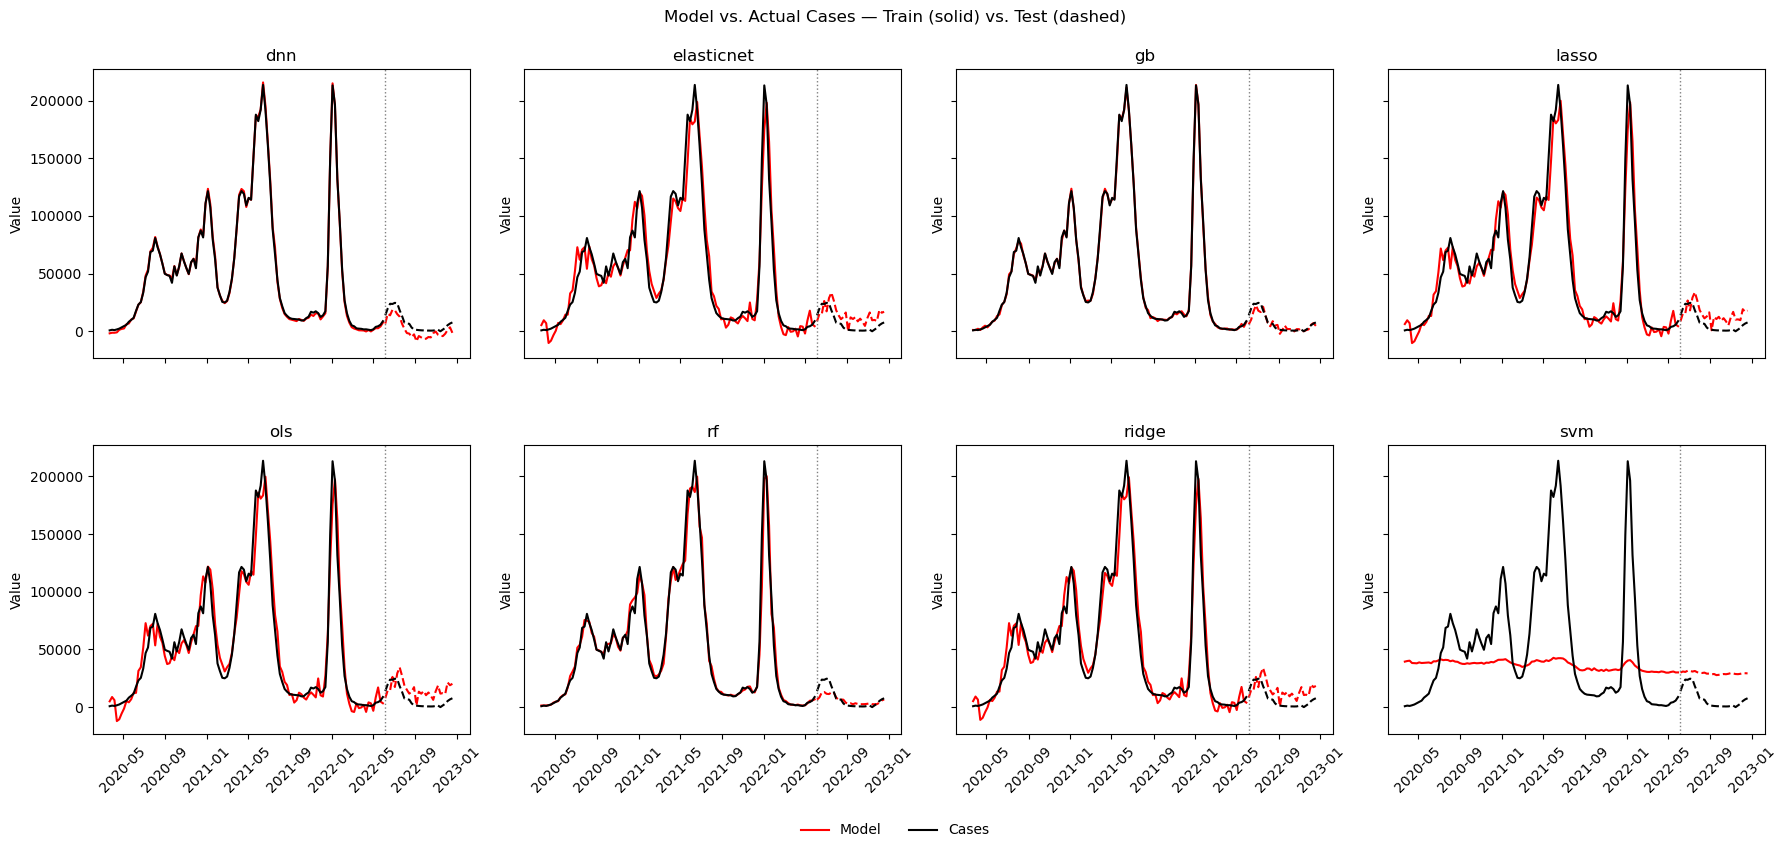

In [29]:
file_name = 'covid_colombia_train_test_mv'
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_col.columns[3:]                     # 8 model columns 
train_df = df_col[df_col['train_test'] == 'train']
test_df  = df_col[df_col['train_test'] == 'test']

split_date = test_df['date'].min()               # first test date → vertical line

# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['cases_1'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['cases_1'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
# save figure in output_dir as pdf
plt.savefig(f'{output_dir}{file_name}.pdf', bbox_inches='tight')
plt.show()

## Epidemics

In [30]:
epidemics_files

['../results\\ARIMA_epidemics.csv',
 '../results\\BM_epidemics.csv',
 '../results\\DNN_epidemics.csv',
 '../results\\ElasticNet_epidemics.csv',
 '../results\\GB_epidemics.csv',
 '../results\\GGM-ARIMA_epidemics.csv',
 '../results\\GGM_epidemics.csv',
 '../results\\Lasso_epidemics.csv',
 '../results\\OLS_epidemics.csv',
 '../results\\Prophet_epidemics.csv',
 '../results\\RF_epidemics.csv',
 '../results\\Ridge_epidemics.csv',
 '../results\\RNN_epidemics.csv',
 '../results\\SEIR_epidemics.csv',
 '../results\\SIR_epidemics.csv',
 '../results\\SVM_epidemics.csv']

In [31]:
epidemics_files_mv = [
 '../results\\DNN_epidemics.csv',
 '../results\\ElasticNet_epidemics.csv',
 '../results\\GB_epidemics.csv',
 '../results\\Lasso_epidemics.csv',
 '../results\\OLS_epidemics.csv',
 '../results\\RF_epidemics.csv',
 '../results\\Ridge_epidemics.csv',
 '../results\\SVM_epidemics.csv']

### Dengue

In [32]:
df_epidemics

,dengue,zika,chikungunya,varicella,date,tavg,tmin,tmax,prcp,wdir,...,no2,o3,pm10,pm25,so2,dengue_1,chikungunya_1,varicella_1,zika_1,set
0,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,180.781498,...,7.164286,18.142857,48.857143,118.285714,0.742857,1006.0,4.0,275.0,1.0,train
1,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,82.957584,...,6.228571,13.057143,25.214286,63.214286,0.628571,931.0,2.0,212.0,3.0,train
2,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,54.720690,...,4.700000,11.757143,15.214286,37.285714,0.614286,883.0,0.0,188.0,1.0,train
3,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,158.256566,...,7.000000,12.092857,31.571429,74.785714,0.642857,879.0,3.0,195.0,3.0,train
4,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,121.429786,...,7.192857,9.607143,23.071429,53.500000,0.442857,801.0,1.0,171.0,0.0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,2317,1.0,3.0,587.0,2023-10-30,18.657551,15.083127,24.168605,7.646682,257.363475,...,12.092857,4.257143,31.500000,60.428571,0.642857,2474.0,1.0,594.0,1.0,test
189,2474,1.0,1.0,594.0,2023-11-06,19.792501,15.418182,25.004676,4.814701,115.917758,...,10.614286,5.700000,27.428571,49.500000,0.557143,2788.0,2.0,610.0,0.0,test
190,2788,0.0,2.0,610.0,2023-11-13,19.562503,14.775730,25.483222,6.250190,180.664470,...,10.821429,5.321429,28.571429,50.357143,0.757143,3026.0,1.0,532.0,3.0,test
191,3026,3.0,1.0,532.0,2023-11-20,18.980349,14.155596,24.829612,4.704982,164.645892,...,9.985714,4.442857,33.071429,55.714286,0.585714,3118.0,1.0,459.0,0.0,test


In [33]:
df_dengue = df_epidemics[['date', 'dengue_1', 'set']].copy()
df_dengue['date'] = pd.to_datetime(df_dengue['date'])
df_dengue

,date,dengue_1,set
0,2020-03-23,1006.0,train
1,2020-03-30,931.0,train
2,2020-04-06,883.0,train
3,2020-04-13,879.0,train
4,2020-04-20,801.0,train
...,...,...,...
188,2023-10-30,2474.0,test
189,2023-11-06,2788.0,test
190,2023-11-13,3026.0,test
191,2023-11-20,3118.0,test


In [34]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in epidemics_files_mv:
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_d = df_temp[['date', 'dengue_1']]
    df_temp_d.columns = ['date', model]
    df_dengue = df_dengue.merge(df_temp_d, on='date', how='left')
    

In [35]:
df_dengue

,date,dengue_1,set,dnn,elasticnet,gb,lasso,ols,rf,ridge,svm
0,2020-03-23,1006.0,train,995.41760,874.206583,963.524456,875.035372,885.563233,962.974583,878.573956,856.795609
1,2020-03-30,931.0,train,921.05743,898.590590,940.824303,930.715877,924.355000,926.840000,908.871474,905.796111
2,2020-04-06,883.0,train,845.61456,825.584511,883.192861,868.014078,854.737671,882.906875,837.222538,842.283853
3,2020-04-13,879.0,train,858.83290,830.107286,894.567789,844.194771,850.237202,865.972500,837.926532,824.004011
4,2020-04-20,801.0,train,827.24450,814.682119,839.076087,839.677178,838.399068,813.361429,824.030951,817.744507
...,...,...,...,...,...,...,...,...,...,...,...
188,2023-10-30,2474.0,test,1898.01460,2216.651487,1346.216174,2243.698270,2254.338877,1280.872583,2232.196066,2224.001134
189,2023-11-06,2788.0,test,1937.10060,2344.657225,1307.894572,2384.929349,2391.224501,1281.169167,2363.808510,2360.485789
190,2023-11-13,3026.0,test,2188.46390,2634.700269,1349.660607,2684.084943,2695.352715,1290.317500,2659.452489,2652.697139
191,2023-11-20,3118.0,test,2358.04420,2847.076992,1261.097697,2903.224187,2916.987785,1314.651667,2875.522459,2866.863594


In [36]:
output_dir = '../latex_plots/'

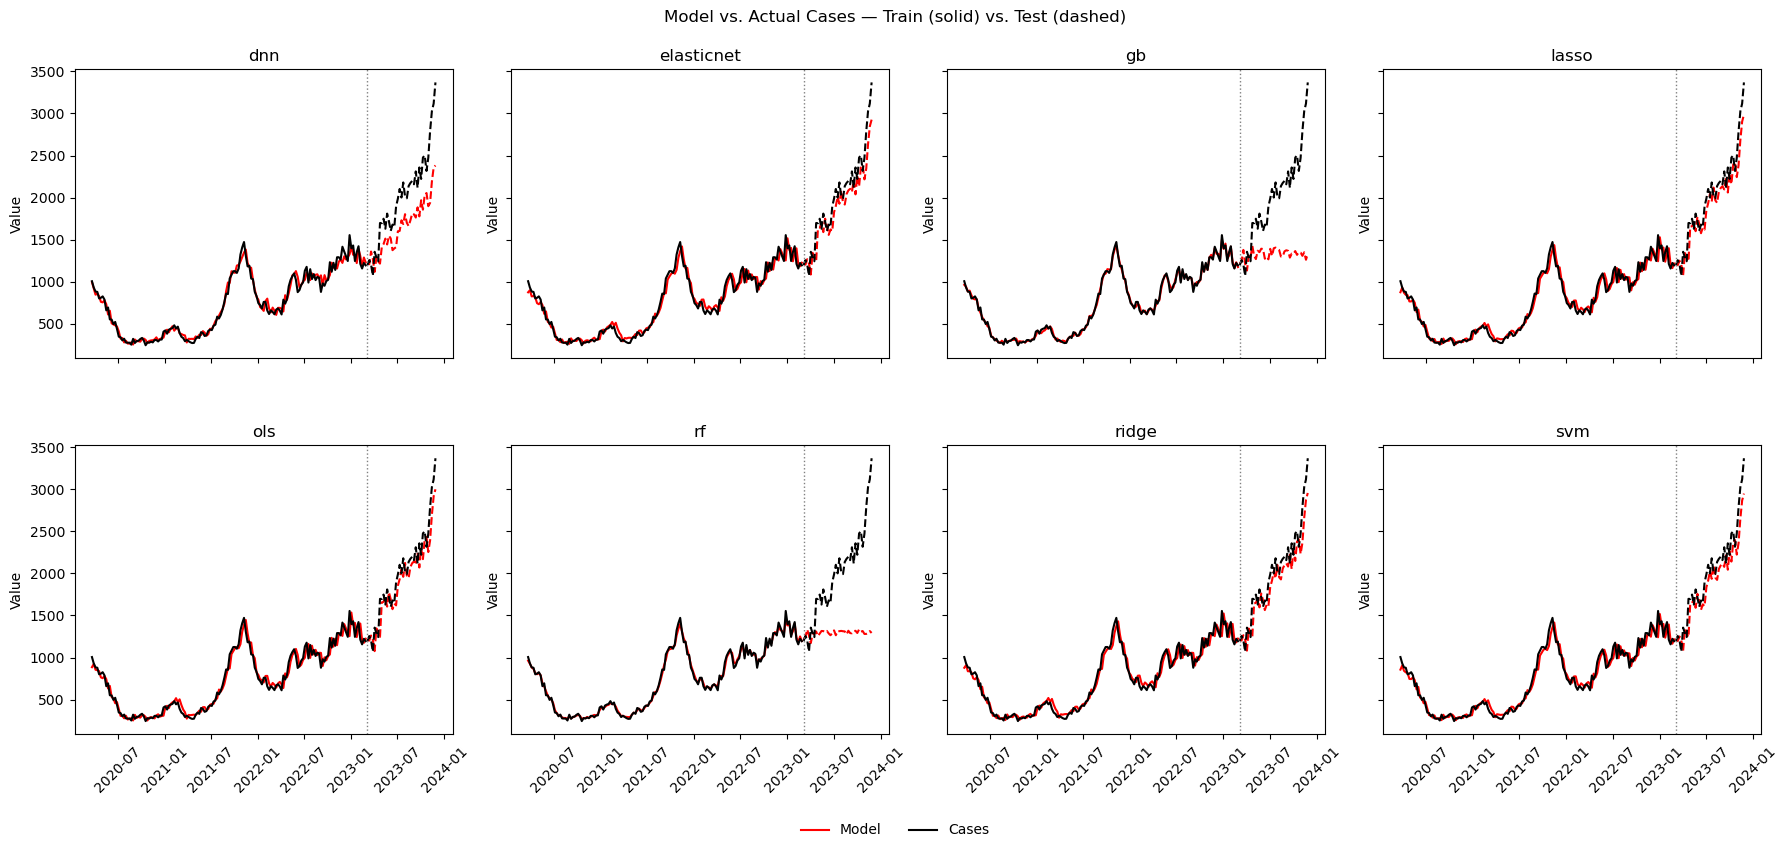

In [37]:
file_name = 'dengue_train_test_mv'
# ------------------------------------------------------------------
# 1.  Split into train / test & choose the 8 model columns
# ------------------------------------------------------------------
y_cols   = df_dengue.columns[3:]                     # 8 model columns 
train_df = df_dengue[df_dengue['set'] == 'train']
test_df  = df_dengue[df_dengue['set'] == 'test']
split_date = test_df['date'].min()               # first test date → vertical line


# ------------------------------------------------------------------
# 2.  2 × 4 grid
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 4, figsize=(18, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # --------------------------------------------------------------
    # Model predictions : red
    # --------------------------------------------------------------
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # --------------------------------------------------------------
    # Actual cases       : black
    # --------------------------------------------------------------
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['dengue_1'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['dengue_1'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    ax.set_title(col)
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3.  Shared legend (labels defined only in first subplot)
# ------------------------------------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])   # leave space below for legend
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03)
plt.subplots_adjust(hspace=0.3)  # space between rows
# save the figure as pdf in the output_dir
fig.savefig(output_dir + file_name + '.pdf', bbox_inches='tight')
plt.show()

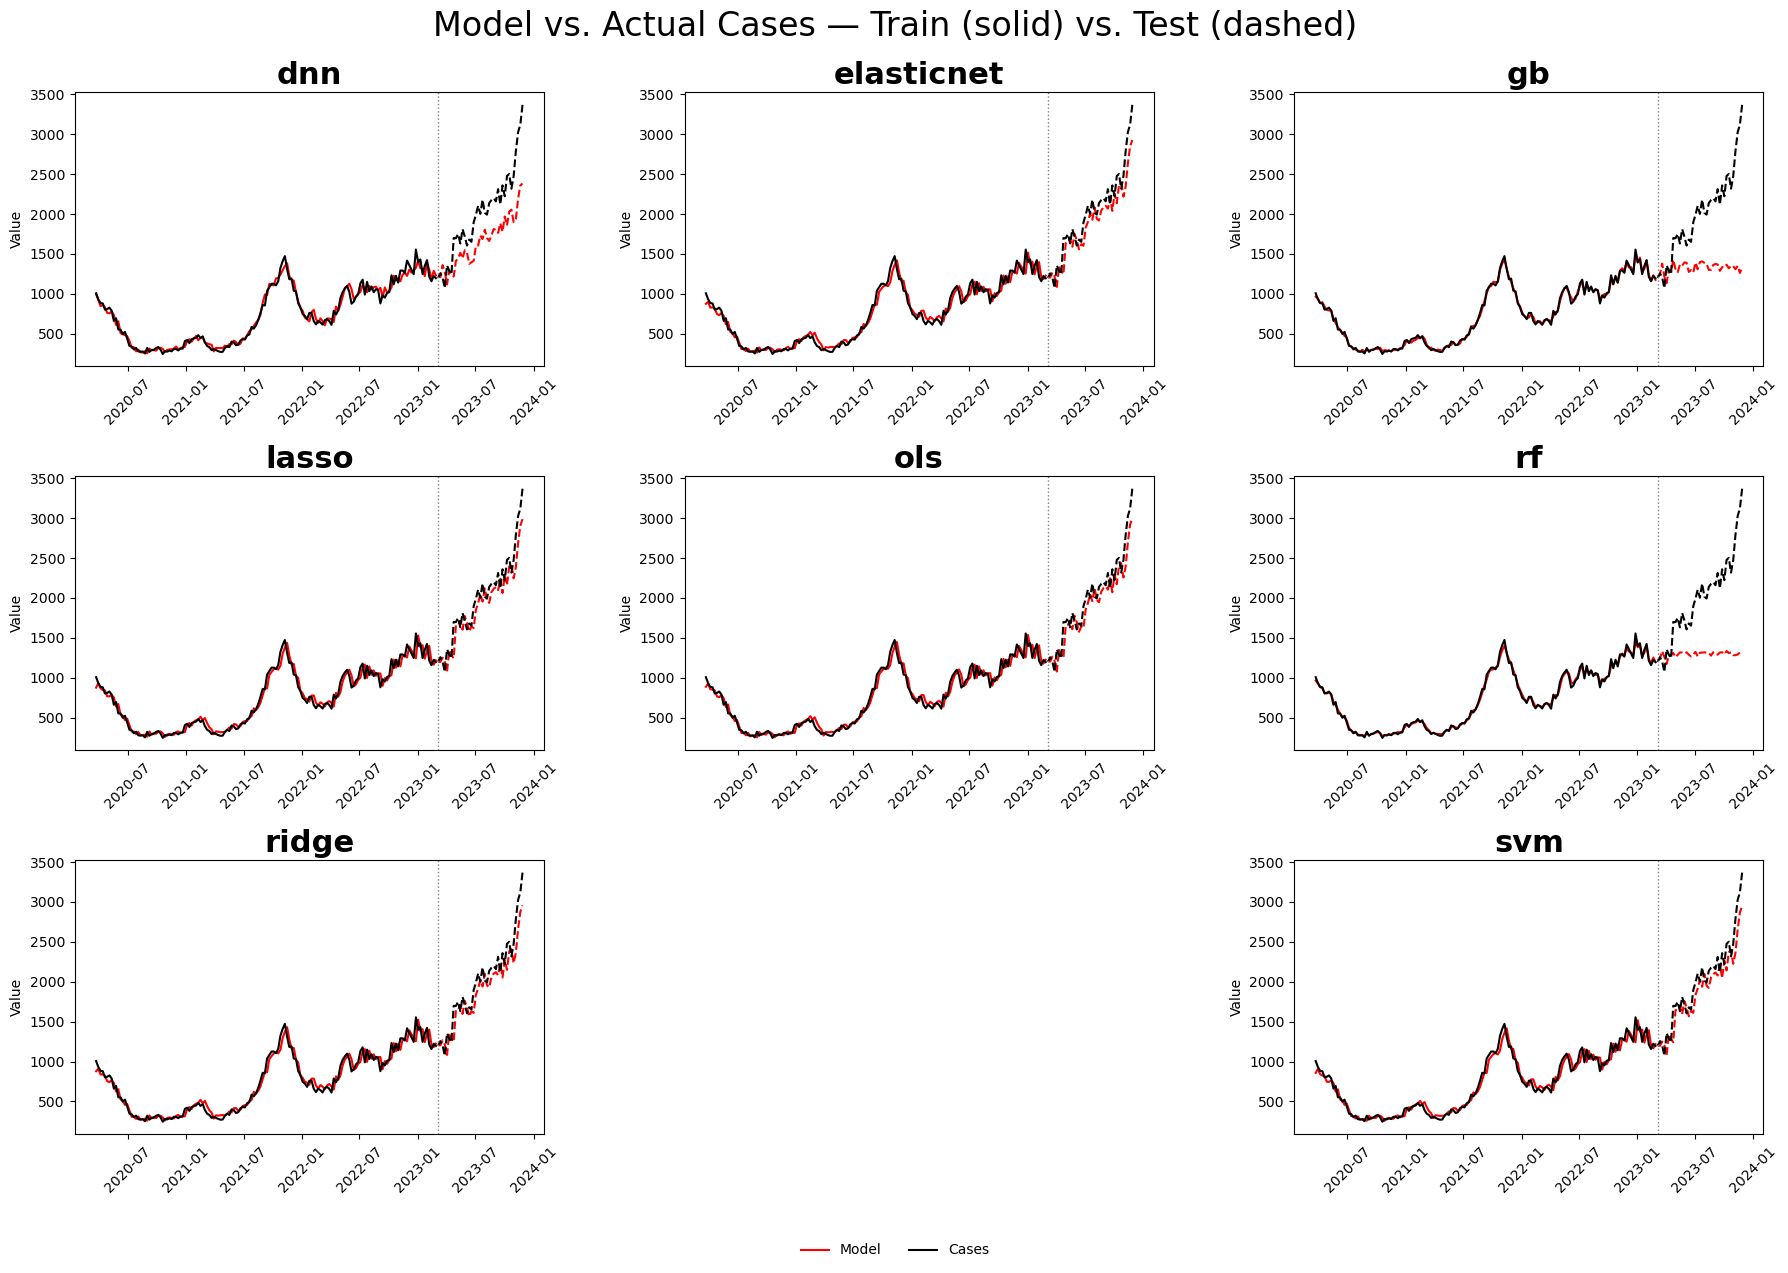

In [38]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
# Assuming df_dengue, y_cols, train_df, test_df, split_date, and output_dir are defined

file_name = 'dengue_train_test_mv_slides'

# ------------------------------------------------------------------
# 1. Define the custom 3x3 grid using GridSpec
#    This replaces the old plt.subplots(2, 4) call.
# ------------------------------------------------------------------
# Use a taller figure size to accommodate 3 rows
fig = plt.figure(figsize=(18, 12))
gs = gridspec.GridSpec(3, 3, figure=fig)

axes = []

# First 6 subplots: fill the first two rows
for i in range(6):
    ax = fig.add_subplot(gs[i // 3, i % 3])
    axes.append(ax)

# Last 2 subplots: place them in the corners of the last row for a centered look
ax7 = fig.add_subplot(gs[2, 0])
ax8 = fig.add_subplot(gs[2, 2])
axes.extend([ax7, ax8])


# ------------------------------------------------------------------
# 2. The plotting loop remains the same, but with updated titles
# ------------------------------------------------------------------
for i, (ax, col) in enumerate(zip(axes, y_cols)):
    # Model predictions : red
    lbl_model = 'Model' if i == 0 else None
    ax.plot(train_df['date'], train_df[col],  color='red', label=lbl_model)
    ax.plot(test_df['date'],  test_df[col],   color='red', linestyle='--')

    # Actual cases     : black (using 'dengue_1' as in your original script)
    lbl_cases = 'Cases' if i == 0 else None
    ax.plot(train_df['date'], train_df['dengue_1'], color='black', label=lbl_cases)
    ax.plot(test_df['date'],  test_df['dengue_1'],  color='black', linestyle='--')

    # vertical separator
    ax.axvline(split_date, color='grey', linestyle=':', lw=1)

    # Use the larger, bolded titles from the first plot's style
    ax.set_title(col, fontsize=22, fontweight='bold')
    ax.set_ylabel('Value')
    ax.tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------
# 3. Finalization code remains the same
# ------------------------------------------------------------------
# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center',
           ncol=2, frameon=False, bbox_to_anchor=(0.5, -0.02))

fig.tight_layout(rect=[0, 0.03, 1, 1])
fig.suptitle('Model vs. Actual Cases — Train (solid) vs. Test (dashed)', y=1.03, fontsize=24) # Increased suptitle font
plt.subplots_adjust(hspace=0.4, wspace=0.3) # Increased spacing for larger titles

# save the figure as pdf in the output_dir
fig.savefig(output_dir + file_name + '.pdf', bbox_inches='tight')
plt.show()

# Metrics

In [83]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Covid

In [84]:
df_base = pd.DataFrame()

In [85]:
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in covid_files_mv:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_long = df_temp.melt(id_vars=['date'], var_name='country', value_name='value')
    df_temp_long['model'] = model
    df_base = pd.concat([df_base, df_temp_long], axis=0)
    

processing file:  ../results\DNN_covid.csv
processing file:  ../results\ElasticNet_covid.csv
processing file:  ../results\GB_covid.csv
processing file:  ../results\Lasso_covid.csv
processing file:  ../results\OLS_covid.csv
processing file:  ../results\RF_covid.csv
processing file:  ../results\Ridge_covid.csv
processing file:  ../results\SVM_covid.csv


In [86]:
df_base

,date,country,value,model
0,2020-03-23,Chile,6093.791500,dnn
1,2020-03-30,Chile,2423.451400,dnn
2,2020-04-06,Chile,3420.029500,dnn
3,2020-04-13,Chile,7227.117700,dnn
4,2020-04-20,Chile,8814.203000,dnn
...,...,...,...,...
715,2022-11-21,US,468972.322128,svm
716,2022-11-28,US,467004.835182,svm
717,2022-12-05,US,469017.917021,svm
718,2022-12-12,US,468285.423773,svm


In [88]:
df_covid.head()

,date,country,new_cases,cases,co,no2,o3,pm10,pm25,so2,population,google_physician,google_hospital,google_pharmacy,google_symptom,Mean_distance_avg_14day_movavg,StringencyIndex_Average,pop_vaccinated,cases_1,train_test
0,2020-03-23,Chile,1558,10261,5.828571,5.242857,10.619048,28.350649,37.952381,3.773810,19331414,30,8,9,32,19.456667,69.844286,0.0,2420.0,train
1,2020-03-30,Chile,2420,24909,5.978571,6.516667,13.771429,38.922078,50.726190,4.035714,19331414,27,7,10,28,12.998571,75.930000,0.0,2987.0,train
2,2020-04-06,Chile,2987,43938,6.235714,6.992857,12.733333,43.142857,66.071429,3.840476,19331414,28,7,9,25,11.041429,75.930000,0.0,3304.0,train
3,2020-04-13,Chile,3304,65523,7.383333,8.771429,11.707143,43.233766,69.059524,4.076190,19331414,28,6,9,21,10.270000,75.930000,0.0,4054.0,train
4,2020-04-20,Chile,4054,90640,6.742857,6.788095,11.769048,38.662338,63.321429,3.661905,19331414,24,6,9,21,10.878571,75.930000,0.0,7431.0,train


In [89]:
df_covid_temp = df_covid[['date', 'country', 'cases_1']].copy()
df_covid_temp['date'] = pd.to_datetime(df_covid_temp['date'])

### Ranking of RMSE

In [97]:
countries = df_base['country'].unique()
models = df_base['model'].unique()
n_countries = len(countries)
n_models = len(models)
rmse_matrix = np.zeros((n_countries, n_models))
r2_matrix = np.zeros((n_countries, n_models))

In [98]:
# loop over countries
for i in range(n_countries):
    country = countries[i] # set the country
    df_country = df_covid_temp[df_covid_temp['country'] == country].copy() # get the data for the country
    df_country.reset_index(drop=True, inplace=True) # reset the index
    y_true = df_country[(df_country['country'] == country)]['cases_1'] # get the true values
    split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
    y_test_true = y_true[split_point:] # get the test values
    # loop over models
    for j in range(n_models):
        
        model = models[j] # set the model
        # get the test data for the country i and model j
        df_fitted_temp = df_base[(df_base['country'] == country) & (df_base['model'] == model)].copy() # get the data for the country and model
        df_fitted_temp.reset_index(drop=True, inplace=True)
        y_pred = df_fitted_temp['value']
        y_pred_test = y_pred[split_point:]
        
        # calculate the metrics
        rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
        r2 = r2_score(y_test_true, y_pred_test)
        rmse_matrix[i,j] = rmse
        r2_matrix[i,j] = r2
        
# create a dataframe with the metrics
df_rmse = pd.DataFrame(rmse_matrix, columns=models, index=countries)
df_r2 = pd.DataFrame(r2_matrix, columns=models, index=countries)

In [99]:
df_rmse_t = df_rmse.transpose()
df_r2_t = df_r2.transpose()
# create mean columns
#df_rmse_t['mean'] = df_rmse_t.mean(axis=1)
#df_r2_t['mean'] = df_r2_t.mean(axis=1)

In [100]:
ranks_rmse = {}
for country in df_rmse_t.columns:
    ranks_rmse[country] = df_rmse_t[country].rank(ascending=True, method='min')

In [101]:
# ranks_rmse to dataframe
df_ranks_rmse = pd.DataFrame(ranks_rmse)
df_ranks_rmse['mean'] = df_ranks_rmse.mean(axis=1) # mean of the ranks
df_ranks_rmse

,Chile,Colombia,Italy,Mexico,US,mean
dnn,1.0,3.0,5.0,1.0,2.0,2.4
elasticnet,4.0,4.0,2.0,4.0,5.0,3.8
gb,6.0,2.0,6.0,2.0,8.0,4.8
lasso,3.0,6.0,1.0,3.0,4.0,3.4
ols,2.0,7.0,4.0,6.0,7.0,5.2
rf,7.0,1.0,7.0,7.0,1.0,4.6
ridge,5.0,5.0,3.0,5.0,6.0,4.8
svm,8.0,8.0,8.0,8.0,3.0,7.0


In [102]:
df_ranks_rmse.sort_values(by='mean', ascending=True, inplace=True)

In [103]:
output_dir = '../latex_plots/'

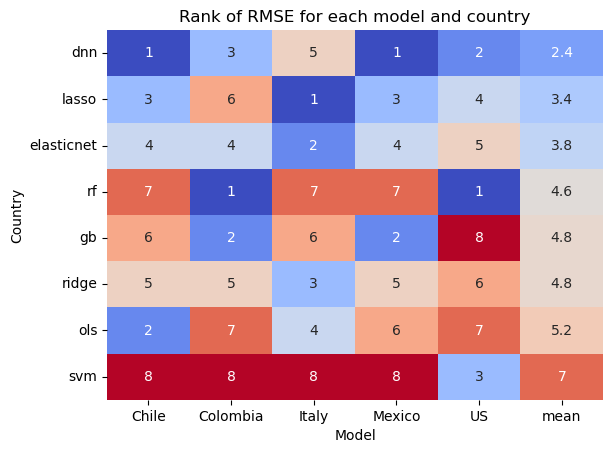

In [104]:

plot_name = 'rank_rmse_covid_mv'
sns.heatmap(df_ranks_rmse, annot=True, cmap='coolwarm', cbar=False)
plt.title('Rank of RMSE for each model and country')
plt.xlabel('Model')
plt.ylabel('Country')
# save plot in output_dir as pdf
plt.savefig(f'{output_dir}{plot_name}.pdf', bbox_inches='tight')
plt.show()

## Epidemics

In [105]:
df_epidemics.rename(columns={'dengue': 'Dengue',
                             'zika':'Zika',
                             'chik': 'Chikungunya',
                             'var': 'Varicella'}, inplace=True)
df_epidemics.head()

,Dengue,Zika,chikungunya,varicella,date,tavg,tmin,tmax,prcp,wdir,...,no2,o3,pm10,pm25,so2,dengue_1,chikungunya_1,varicella_1,zika_1,set
0,949,3.0,1.0,351.0,2020-03-23,20.003080,14.529673,25.878470,1.866561,180.781498,...,7.164286,18.142857,48.857143,118.285714,0.742857,1006.0,4.0,275.0,1.0,train
1,1006,1.0,4.0,275.0,2020-03-30,20.310320,15.607637,25.801951,4.628407,82.957584,...,6.228571,13.057143,25.214286,63.214286,0.628571,931.0,2.0,212.0,3.0,train
2,931,3.0,2.0,212.0,2020-04-06,20.567575,15.800335,25.874548,3.028124,54.720690,...,4.700000,11.757143,15.214286,37.285714,0.614286,883.0,0.0,188.0,1.0,train
3,883,1.0,0.0,188.0,2020-04-13,19.564572,14.112981,25.608096,2.240946,158.256566,...,7.000000,12.092857,31.571429,74.785714,0.642857,879.0,3.0,195.0,3.0,train
4,879,3.0,3.0,195.0,2020-04-20,19.833153,14.608703,25.966335,4.637722,121.429786,...,7.192857,9.607143,23.071429,53.500000,0.442857,801.0,1.0,171.0,0.0,train


In [108]:
df_epidemics_temp = df_epidemics[['date', 'dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1']].copy()
df_epidemics_temp['date'] = pd.to_datetime(df_epidemics_temp['date'])

In [109]:
df_epidemics_temp.head()

,date,dengue_1,zika_1,chikungunya_1,varicella_1
0,2020-03-23,1006.0,1.0,4.0,275.0
1,2020-03-30,931.0,3.0,2.0,212.0
2,2020-04-06,883.0,1.0,0.0,188.0
3,2020-04-13,879.0,3.0,3.0,195.0
4,2020-04-20,801.0,0.0,1.0,171.0


In [110]:
df_base = pd.DataFrame()
file = epidemics_files_mv[0]
model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
model  = model.lower()  # convert to lower case
print(model)
df_temp = pd.read_csv(file)
df_temp['date'] = pd.to_datetime(df_temp['date'])
df_temp_long = df_temp.melt(id_vars=['date'], var_name='epidemic', value_name='value')
df_temp_long['model'] = model
df_base = pd.concat([df_base, df_temp_long], axis=0)
df_base

dnn


,date,epidemic,value,model
0,2020-03-23,dengue_1,995.41760,dnn
1,2020-03-30,dengue_1,921.05743,dnn
2,2020-04-06,dengue_1,845.61456,dnn
3,2020-04-13,dengue_1,858.83290,dnn
4,2020-04-20,dengue_1,827.24450,dnn
...,...,...,...,...
779,2023-11-20,varicella_1,508.33557,dnn
780,2023-11-27,varicella_1,452.27368,dnn
781,2023-12-04,varicella_1,402.67828,dnn
782,2023-12-11,varicella_1,440.03950,dnn


In [111]:
df_base = pd.DataFrame()
# read covid_files_ts in a loop and append the column Colombia to df_col, change name to model
for file in epidemics_files_mv:
    print('processing file: ', file)
    model = file.split('\\')[-1].split('_')[0]  # get the model name from the file name
    model  = model.lower()  # convert to lower case
    df_temp = pd.read_csv(file)
    df_temp['date'] = pd.to_datetime(df_temp['date'])
    df_temp_long = df_temp.melt(id_vars=['date'], var_name='epidemic', value_name='value')
    df_temp_long['model'] = model
    df_base = pd.concat([df_base, df_temp_long], axis=0)

processing file:  ../results\DNN_epidemics.csv
processing file:  ../results\ElasticNet_epidemics.csv
processing file:  ../results\GB_epidemics.csv
processing file:  ../results\Lasso_epidemics.csv
processing file:  ../results\OLS_epidemics.csv
processing file:  ../results\RF_epidemics.csv
processing file:  ../results\Ridge_epidemics.csv
processing file:  ../results\SVM_epidemics.csv


In [112]:
df_base['epidemic'].unique()

array(['dengue_1', 'zika_1', 'chikungunya_1', 'varicella_1'], dtype=object)

### Ranking of RMSE

In [113]:
epidemics = df_base['epidemic'].unique()
models = df_base['model'].unique()
n_epidemics = len(epidemics)
n_models = len(models)
rmse_matrix = np.zeros((n_epidemics, n_models))
r2_matrix = np.zeros((n_epidemics, n_models))

In [114]:
df_epidemics_temp.head()

,date,dengue_1,zika_1,chikungunya_1,varicella_1
0,2020-03-23,1006.0,1.0,4.0,275.0
1,2020-03-30,931.0,3.0,2.0,212.0
2,2020-04-06,883.0,1.0,0.0,188.0
3,2020-04-13,879.0,3.0,3.0,195.0
4,2020-04-20,801.0,0.0,1.0,171.0


In [115]:
# loop over countries
for i in range(n_epidemics):
    #print('processing epidemic: ', epidemics[i])
    epidemic = epidemics[i] # set the country
    df_epidemic = df_epidemics_temp[['date', epidemic]].copy() # get the data for the epidemic
    df_epidemic.rename(columns={epidemic: 'cases'}, inplace=True)
    df_epidemic.dropna(subset='cases', inplace=True)
    df_epidemic.reset_index(drop=True, inplace=True) # reset the index
    
    # loop over models
    for j in range(n_models):
        #print('processing model: ', models[j])
        
        model = models[j] # set the model
        # get the test data for the country i and model j
        df_fitted_temp = df_base[(df_base['epidemic'] == epidemic) & (df_base['model'] == model)].copy() # get the data for the country and model
        df_fitted_temp.dropna(subset = ['value'], inplace=True)
        df_fitted_temp.reset_index(drop=True, inplace=True)
        # create a temporal df merged by date
        df_temp_merge = df_epidemic.merge(df_fitted_temp, on='date', how='outer')
        # interpolate the missing values in the value column
        df_temp_merge['value'] = df_temp_merge['value'].interpolate(method='linear')
        
        # drop the rows with missing values
        df_temp_merge.dropna(subset=['cases', 'value'], inplace=True)
        # get true and pred values
        y_true = df_temp_merge['cases'] # get the true values
        split_point = int(len(y_true) * 0.8)        # row where the 80/20 cut happens
        y_test_true = y_true[split_point:] # get the test values


        y_pred = df_temp_merge['value']
        y_pred_test = y_pred[split_point:]


        # calculate the metrics
        rmse = np.sqrt(mean_squared_error(y_test_true, y_pred_test))
        r2 = r2_score(y_test_true, y_pred_test)
        rmse_matrix[i,j] = rmse
        r2_matrix[i,j] = r2
        
# create a dataframe with the metrics
df_rmse = pd.DataFrame(rmse_matrix, columns=models, index=epidemics)
df_r2 = pd.DataFrame(r2_matrix, columns=models, index=epidemics)

In [116]:
df_rmse_t = df_rmse.transpose()
df_r2_t = df_r2.transpose()
# create mean columns
#df_rmse_t['mean'] = df_rmse_t.mean(axis=1)
#df_r2_t['mean'] = df_r2_t.mean(axis=1)

In [117]:
ranks_rmse = {}
for epidemic in df_rmse_t.columns:
    ranks_rmse[epidemic] = df_rmse_t[epidemic].rank(ascending=True, method='min')

In [118]:
# ranks_rmse to dataframe
df_ranks_rmse = pd.DataFrame(ranks_rmse)
df_ranks_rmse['mean'] = df_ranks_rmse.mean(axis=1) # mean of the ranks
df_ranks_rmse

,dengue_1,zika_1,chikungunya_1,varicella_1,mean
dnn,6.0,5.0,5.0,6.0,5.50
elasticnet,5.0,6.0,3.0,4.0,4.50
gb,7.0,8.0,8.0,7.0,7.50
lasso,2.0,6.0,1.0,5.0,3.50
ols,1.0,2.0,6.0,2.0,2.75
rf,8.0,4.0,7.0,8.0,6.75
ridge,3.0,3.0,2.0,3.0,2.75
svm,4.0,1.0,4.0,1.0,2.50


In [119]:
df_ranks_rmse.sort_values(by='mean', ascending=True, inplace=True)

In [120]:
output_dir = '../latex_plots/'

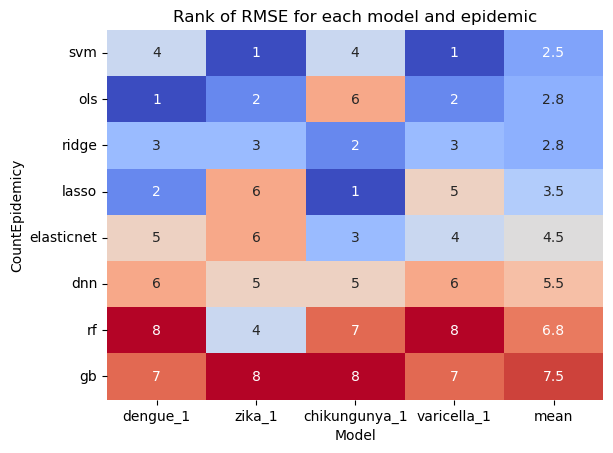

In [121]:

plot_name = 'rank_rmse_epidemics_mv'
sns.heatmap(df_ranks_rmse, annot=True, cmap='coolwarm', cbar=False)
plt.title('Rank of RMSE for each model and epidemic')
plt.xlabel('Model')
plt.ylabel('CountEpidemicy')
# save plot in output_dir as pdf
plt.savefig(f'{output_dir}{plot_name}.pdf', bbox_inches='tight')
plt.show()